In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

rfm = pd.read_csv('../data/rfm_scores.csv')
print(rfm.shape)
print(rfm.head())

(93350, 9)
                 customer_unique_id  recency  frequency  monetary  r_score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90        4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19        4   
2  0000f46a3911fa3c0805444483337064      537          1     86.22        1   
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62        2   
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89        2   

   f_score  m_score  rfm_score        segment  
0        1        4        414  New Customers  
1        1        1        411  New Customers  
2        1        2        112           Lost  
3        1        1        211           Lost  
4        1        4        214           Lost  


In [2]:
# select only the 3 metrics for clustering
X = rfm[['recency', 'frequency', 'monetary']].copy()

# normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("before scaling - mean recency:", X['recency'].mean().round(2))
print("after scaling - mean recency:", X_scaled[:, 0].mean().round(2))

before scaling - mean recency: 237.95
after scaling - mean recency: -0.0


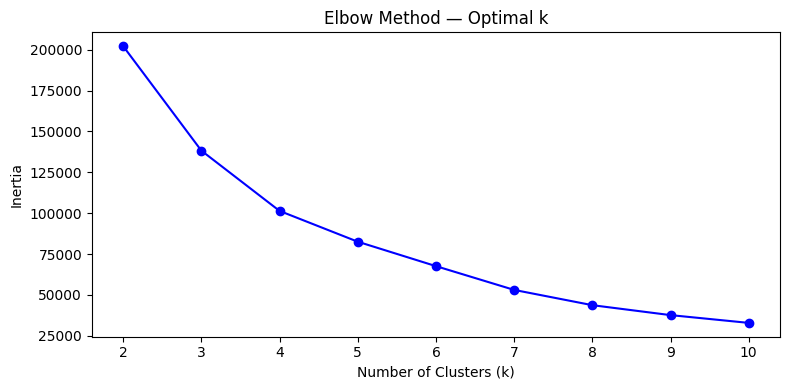

In [3]:
# elbow method to find optimal k
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal k')
plt.tight_layout()
plt.savefig('../images/elbow_plot.png')
plt.show()

In [4]:
# run kmeans with k=4
km = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['cluster'] = km.fit_predict(X_scaled)

# see cluster sizes
print(rfm['cluster'].value_counts())

cluster
0    52140
2    38391
1     2798
3       21
Name: count, dtype: int64


In [5]:
# analyze each cluster's average RFM values
cluster_summary = rfm.groupby('cluster')[['recency', 'frequency', 'monetary']].mean().round(2)
print(cluster_summary)

         recency  frequency  monetary
cluster                              
0         128.48       1.00    198.56
1         220.38       2.11    428.77
2         387.92       1.00    199.24
3         209.33       1.24  27302.18


In [6]:
cluster_labels = {0: 'Recent', 1: 'Loyal', 2: 'Lost', 3: 'High Value'}
rfm['cluster_label'] = rfm['cluster'].map(cluster_labels)
print(rfm['cluster_label'].value_counts())

cluster_label
Recent        52140
Lost          38391
Loyal          2798
High Value       21
Name: count, dtype: int64


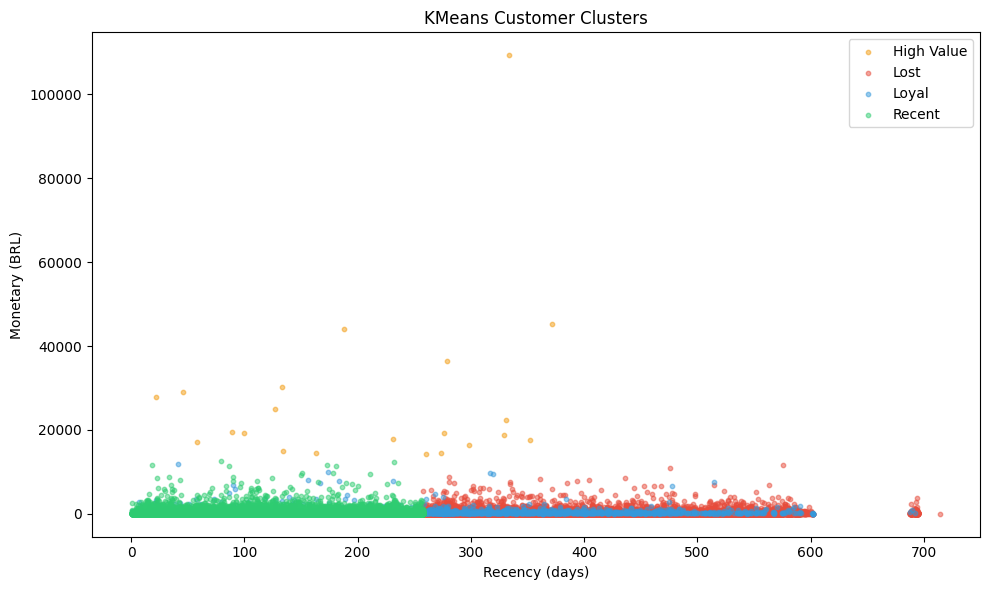

In [7]:
# scatter plot - recency vs monetary, colored by cluster
plt.figure(figsize=(10, 6))
colors = {'Recent': '#2ecc71', 'Loyal': '#3498db', 'Lost': '#e74c3c', 'High Value': '#f39c12'}

for label, group in rfm.groupby('cluster_label'):
    plt.scatter(group['recency'], group['monetary'], 
                c=colors[label], label=label, alpha=0.5, s=10)

plt.xlabel('Recency (days)')
plt.ylabel('Monetary (BRL)')
plt.title('KMeans Customer Clusters')
plt.legend()
plt.tight_layout()
plt.savefig('../images/kmeans_clusters.png')
plt.show()

In [8]:
rfm.to_csv('../data/rfm_with_clusters.csv', index=False)
print("saved.")

saved.
